In [10]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/data')

train_data_path = os.path.join(data_dir, 'train.csv')
sub_data_path = os.path.join(data_dir, 'test.csv')  

<Axes: >

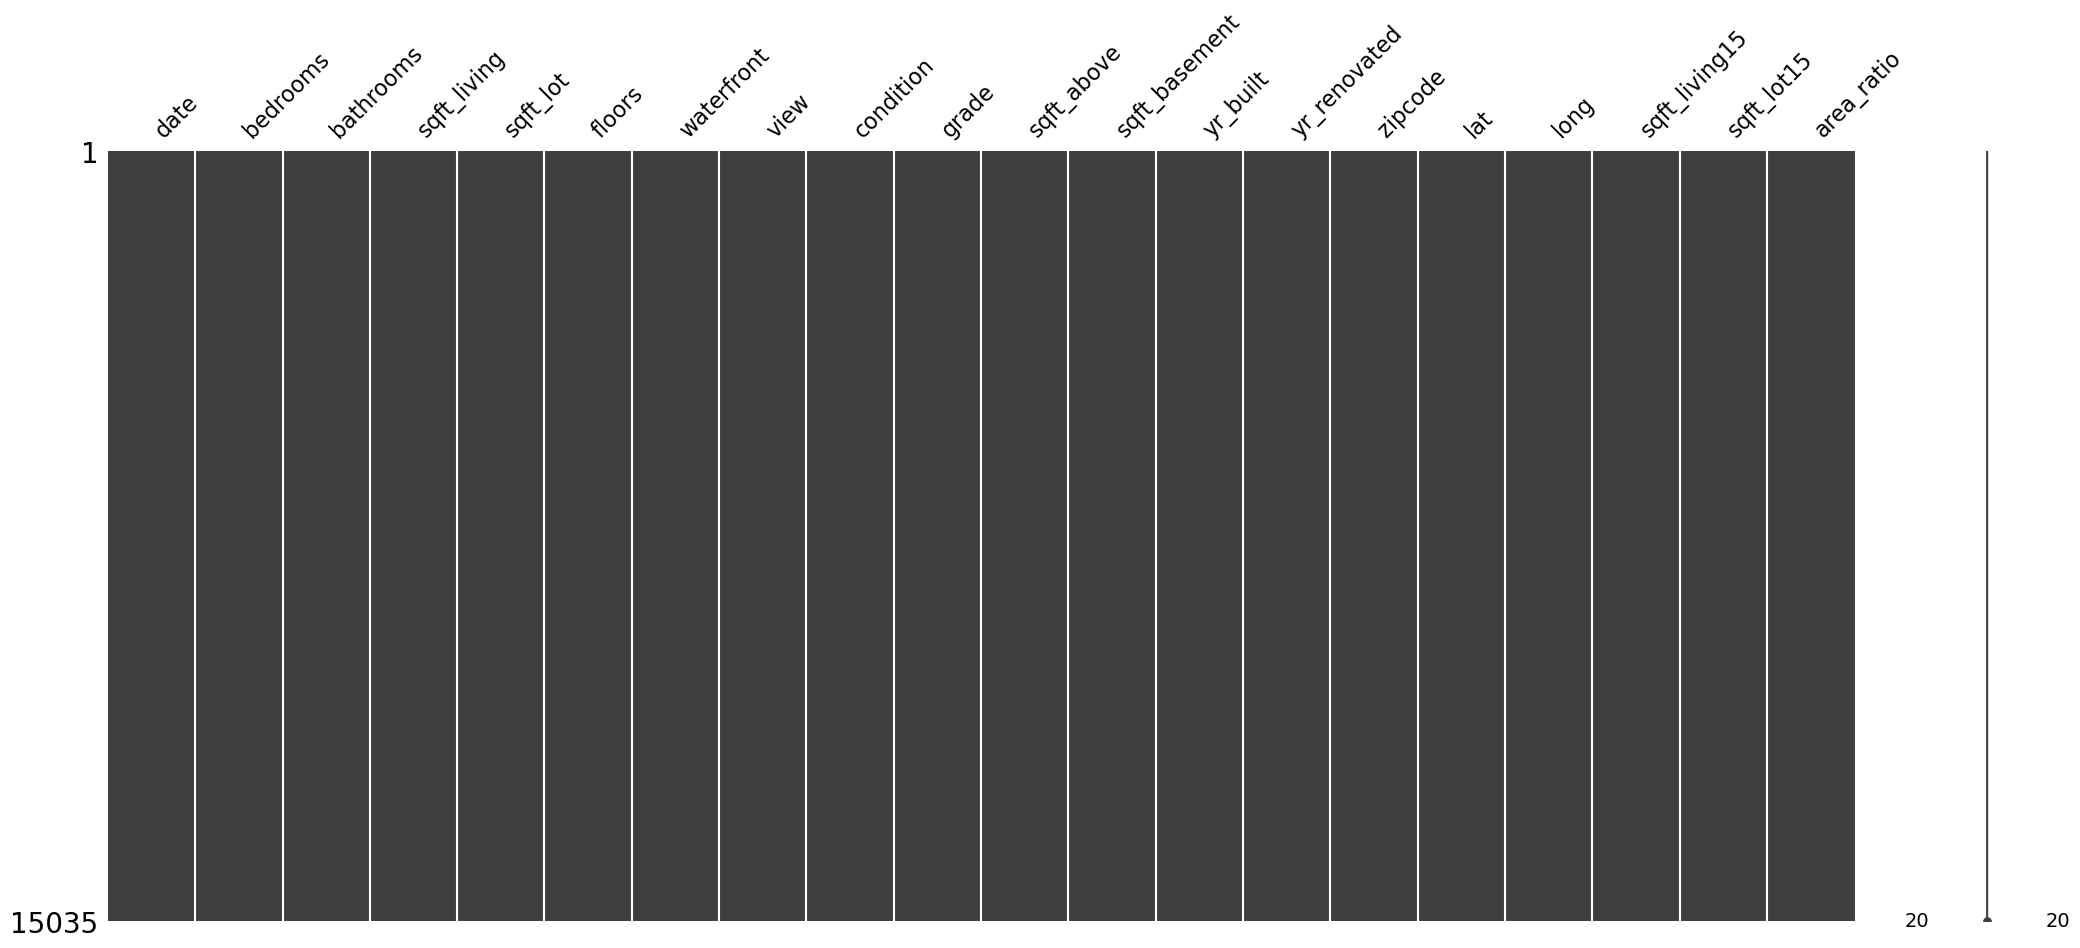

In [11]:
train = pd.read_csv(train_data_path)
test = pd.read_csv(sub_data_path)

train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

y = train['price']
del train['price']

del train['id']
del test['id']

train['area_ratio'] = train['sqft_living'] / train['sqft_lot']
test['area_ratio']  = test['sqft_living']  / test['sqft_lot']

train['zipcode'] = train['zipcode'].astype('category')
test['zipcode']  = test['zipcode'].astype('category')

# sns.kdeplot(y)

# train_len = len(data)
# data = pd.concat((data, sub), axis=0)
msno.matrix(train)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))


from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

random_state=2020        

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

In [6]:
def get_scores(models, train, y):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        df[model_name] = rmse(y_test, y_pred)
        score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

    return score_df

In [13]:
from sklearn.model_selection import GridSearchCV


def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    # GridSearchCV 모델로 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', \
                              cv=5, verbose=verbose, n_jobs=n_jobs)

    # 모델 fitting
    grid_model.fit(train, y)

    # 결과값 저장
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['score'] = score

    # RMSLE 값 계산 후 정렬
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    results = results.sort_values('RMSLE')

    return results

In [14]:
param_grid = {
    'n_estimators': [500, 700, 900],
    'max_depth': [9, 12, 15],
    'learning_rate': [0.08, 0.05],
    'num_leaves' : [15, 20]
}

y_log = np.log1p(y)

model = LGBMRegressor(random_state=random_state)
param_gained = my_GridSearch(model, train, y_log, param_grid, verbose=10, n_jobs=5)

best = param_gained.iloc[0]
print(best)

# 최적 파라미터로 모델 재학습
model = LGBMRegressor(
    max_depth    = int(best['max_depth']),
    n_estimators = int(best['n_estimators']),
    learning_rate= best['learning_rate'],
    num_leaves   = int(best['num_leaves']),
    random_state = random_state
)
model.fit(train, y_log)



# model = LGBMRegressor(param_gained, random_state=random_state)
# model.fit(train, y_log)
# # prediction = model.predict(test)
# # prediction
# prediction = np.expm1(model.predict(test))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 4/5; 1/36] START learning_rate=0.08, max_depth=9, n_estimators=500, num_leaves=15
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011783 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2586
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 20
[LightGBM] [Info] Start training from score 13.050660
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[CV 4/5; 1/36] END learning_rate=0.08, max_depth=9, n_estimators=500, num_leaves=15;, score=-0.026 total time=   5.4s
[CV 5/5; 2/36] START learning_rate=0.08, max_depth=9, n_estimators=500, num_leaves=20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Lig

LGBMRegressor(learning_rate=np.float64(0.05), max_depth=9, n_estimators=900,
              num_leaves=15, random_state=2020)


[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 20
[LightGBM] [Info] Start training from score 13.050187
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[CV 1/5; 24/36] END learning_rate=0.05, max_depth=9, n_estimators=900, num_leaves=20;, score=-0.026 total time=   8.4s
[CV 1/5; 25/36] START learning_rate=0.05, max_depth=12, n_estimators=500, num_leaves=15
[LightGBM] 

In [15]:
def save_submission(model, train, y_log, test, model_name, rmsle=best['RMSLE'].round(4)):
    model.fit(train, y_log)
    # prediction = model.predict(test)
    # prediction = np.expm1(prediction)
    prediction = np .expm1(model.predict(test))
    data_dir = '~/work/kaggle_kakr_housing/data'
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    submission_csv_path = '{}/harry_submission_{}_RMSLE_{}.csv'.format(data_dir, model_name, rmsle)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

print(param_gained.head())

    learning_rate  max_depth  n_estimators  num_leaves     score     RMSLE
22           0.05          9           900          15 -0.025745  0.160453
34           0.05         15           900          15 -0.025753  0.160476
27           0.05         12           700          20 -0.025762  0.160507
29           0.05         12           900          20 -0.025763  0.160507
21           0.05          9           700          20 -0.025783  0.160572


In [16]:
save_submission(model, train, y_log, test, 'lgbm', rmsle='0.6')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2592
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 20
[LightGBM] [Info] Start training from score 13.048122
~/work/kaggle_kakr_housing/data/harry_submission_lgbm_RMSLE_0.6.csv saved!


In [10]:
data_dir = '~/work/kaggle_kakr_housing/data'
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)

submission['price'] = prediction
submission.head()

NameError: name 'prediction' is not defined

In [15]:
print(param_gained.head())

    learning_rate  max_depth  n_estimators  num_leaves     score     RMSLE
6            0.10         10           200          31 -0.026188  0.161828
24           0.10         20           200          31 -0.026245  0.162003
33           0.10         25           200          31 -0.026245  0.162003
15           0.10         15           200          31 -0.026364  0.162371
70           0.05         25           200          63 -0.026446  0.162623


In [16]:
print(param_gained.iloc[0])

learning_rate      0.100000
max_depth         10.000000
n_estimators     200.000000
num_leaves        31.000000
score             -0.026188
RMSLE              0.161828
Name: 6, dtype: float64


In [19]:

def AveragingBlending(models, x, y, sub_x):
    for m in models :
        m['model'].fit(x.values, y)

    predictions = np.column_stack([
        m['model'].predict(sub_x.values) for m in models
    ])
    return np.mean(predictions, axis=1)

y_pred = AveragingBlending(models, x, y, sub)

data_dir = '~/work/kaggle_kakr_housing/data'

submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)

result = pd.DataFrame({
    'id' : sub_id,
    'price' : y_pred
})

result.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 540682.653143


,id,price
0,15035,5.489445e+05
1,15036,4.436552e+05
2,15037,1.345797e+06
3,15038,3.206119e+05
4,15039,3.180479e+05


In [22]:
my_submission_path = join(data_dir, 'harry_submission.csv')
result.to_csv(my_submission_path, index=False)
print(my_submission_path)

~/work/kaggle_kakr_housing/data/harry_submission.csv


In [2]:
print(result.head())

NameError: name 'result' is not defined